In [1]:
import pandas as pd
import numpy as np

In [2]:
retail=pd.read_excel("retail.xlsx")

In [3]:
retail.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
85093,543461,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,4,2011-02-08 13:35:00,5.79,NaN,United Kingdom
104599,545188,22549,PICTURE DOMINOES,3,2011-02-28 15:19:00,1.45,14056.0,United Kingdom
121817,546784,46000S,POLYESTER FILLER PAD 40x40cm,12,2011-03-17 09:49:00,1.45,18189.0,United Kingdom
427954,573406,20727,LUNCH BAG BLACK SKULL.,10,2011-10-30 15:57:00,1.65,14112.0,United Kingdom
432096,573814,22610,PENS ASSORTED FUNNY FACE,72,2011-11-01 11:31:00,0.19,13268.0,United Kingdom


In [4]:
retail.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 105.0 MB


There are null values in Description and CustomerID columns. We decided to fill null values in Category with "Unspecified" and with 1 for "CustomerID" (we treat these as Guest customers who made purchase without login in).

In [5]:
retail["Description"]=retail["Description"].fillna("Unspecified")
retail["CustomerID"]=retail["CustomerID"].fillna(1)

Let's begin preliminary analysis.

In [6]:
retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,11477.223938
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,1.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,12352.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,14382.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16255.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,6777.486244


We can see that Quantity and UnitPrice both reach negative values. We should inspect that closer.

In [7]:
retail.iloc[retail["UnitPrice"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,1.0,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,1.0,United Kingdom


These two records correspond to accounting adjustment rather that sales. We'll drop them from database 
but we'll keep them separately in case we'll need them later.

In [8]:
accounting_adj=retail.iloc[retail["UnitPrice"]<0]

In [9]:
retail.drop(retail.iloc[retail["UnitPrice"]<0].index, inplace=True)

In [10]:
retail.loc[retail["UnitPrice"]==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,Unspecified,56,2010-12-01 11:52:00,0.0,1.0,United Kingdom
1970,536545,21134,Unspecified,1,2010-12-01 14:32:00,0.0,1.0,United Kingdom
1971,536546,22145,Unspecified,1,2010-12-01 14:33:00,0.0,1.0,United Kingdom
1972,536547,37509,Unspecified,1,2010-12-01 14:33:00,0.0,1.0,United Kingdom
1987,536549,85226A,Unspecified,1,2010-12-01 14:34:00,0.0,1.0,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,Unspecified,27,2011-12-08 10:33:00,0.0,1.0,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,1.0,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,1.0,United Kingdom
538554,581408,85175,Unspecified,20,2011-12-08 14:06:00,0.0,1.0,United Kingdom


This data is incomplete and does not carry valuable information so we decided to drop it.

In [11]:
retail.drop(retail.loc[retail["UnitPrice"]==0].index, inplace=True)

Now we do the same with Quantity.

In [12]:
retail.loc[retail["Quantity"]<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


These data appear to represent transactions corresponding to returns. We'll keep these records in separate database.

In [13]:
returns=retail.loc[retail["Quantity"]<0]

In [14]:
retail.drop(retail.loc[retail["Quantity"]<0].index, inplace=True)

In [15]:
retail.loc[retail["Quantity"]==0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [16]:
retail=retail.reset_index(drop=True)

Next we should optimise memory usage by choosing appropriate data types.

In [17]:
retail.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 530104 entries, 0 to 530103
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    530104 non-null  object        
 1   StockCode    530104 non-null  object        
 2   Description  530104 non-null  object        
 3   Quantity     530104 non-null  int64         
 4   InvoiceDate  530104 non-null  datetime64[us]
 5   UnitPrice    530104 non-null  float64       
 6   CustomerID   530104 non-null  float64       
 7   Country      530104 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 102.7 MB


In [18]:
retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,530104.000000,530104,530104.000000,530104.000000
mean,10.542037,2011-07-04 20:16:05.225087,3.907625,11479.895645
min,1.000000,2010-12-01 08:26:00,0.001000,1.000000
25%,1.000000,2011-03-28 12:22:00,1.250000,12352.000000
50%,3.000000,2011-07-20 12:58:00,2.080000,14388.000000
75%,10.000000,2011-10-19 12:39:00,4.130000,16265.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,155.524124,NaN,35.915681,6781.554578


In [19]:
retail=retail.astype({"Quantity":"Int32",
                     "CustomerID":"Int16"
              })

Next, we analyze the frequency of repeated values in object-type columns to decide whether they should be stored as string or categorical data types.

In [20]:
retail["InvoiceNo"].nunique()

19960

In [21]:
retail["StockCode"].nunique()

3922

In [22]:
retail["Description"].nunique()

4026

Due to the high level of repetition, we change data type to categorical.

In [23]:
retail=retail.astype({"InvoiceNo":"category",
                      "StockCode": "category",
                      "Description":"category"
                     })

Now we check for duplicated values.

In [24]:
retail[retail.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
508,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
518,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
528,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
530,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
546,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom
...,...,...,...,...,...,...,...,...
529873,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446,United Kingdom
529887,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
529890,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
529897,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom


In [25]:
retail.drop_duplicates(keep="first", inplace=True, ignore_index=True)

In [26]:
retail[retail.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [27]:
retail.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  category      
 1   StockCode    524878 non-null  category      
 2   Description  524878 non-null  category      
 3   Quantity     524878 non-null  Int32         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  Int16         
 7   Country      524878 non-null  str           
dtypes: Int16(1), Int32(1), category(3), datetime64[us](1), float64(1), str(1)
memory usage: 27.4 MB


We managed to reduce the memory usage from 102.9 MB to 27.5 MB so aprox. by 73%.

In [28]:
returns=returns.astype({"Quantity":"Int32",
                        "CustomerID":"Int16",
                        "InvoiceNo":"category",
                        "StockCode": "category",
                        "Description":"category"
                      })

In [29]:
accounting_adj=accounting_adj.astype({"Quantity":"Int32",
                        "CustomerID":"Int16",
                        "InvoiceNo":"category",
                        "StockCode": "category",
                        "Description":"category"
                      })

In [30]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


Now we add some new columns: Total which contain total amount, Data and Hour (we won't need precise time of transactions.)

In [31]:
retail=retail.assign(Total=retail["Quantity"]*retail["UnitPrice"])
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.3
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [32]:
retail["InvoiceHour"]=(retail["InvoiceDate"].dt.hour).astype("Int8")
retail["InvoiceDate"]=retail["InvoiceDate"].dt.date.astype("datetime64[ns]")

In [33]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850,United Kingdom,15.3,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850,United Kingdom,20.34,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850,United Kingdom,22.0,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850,United Kingdom,20.34,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850,United Kingdom,20.34,8


In [34]:
retail=retail.loc[:,["StockCode","Description","UnitPrice","Quantity","Total","CustomerID","InvoiceNo","InvoiceDate","InvoiceHour","Country"]]

# SALES ANALYSIS

Let's begin with analysis of revenue trends.

In [35]:
(retail["Total"].sum()/1000000).round(2)


np.float64(10.64)

Total revenue was 10,64 mln.

Let's see how the revenue was distributed in time.

In [36]:
sales=retail.groupby("InvoiceDate")[["Total"]].sum()
sales.head()

,Total
InvoiceDate,
2010-12-01,58776.79
2010-12-02,47629.42
2010-12-03,46898.63
2010-12-05,31364.63
2010-12-06,54624.15


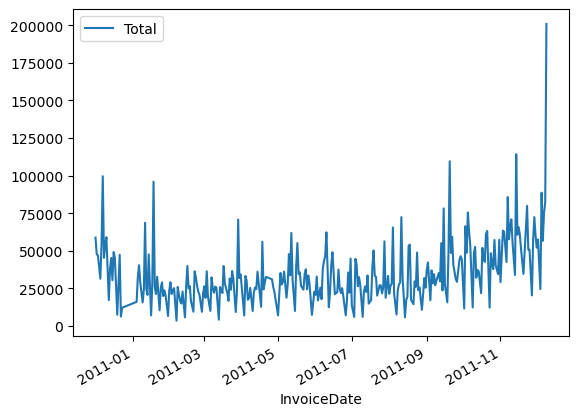

In [37]:
sales.plot();

Let's see how it was changing between months.

In [38]:
monthly_sales=sales.resample("ME").sum()
monthly_sales.index=monthly_sales.index.strftime('%b %Y')

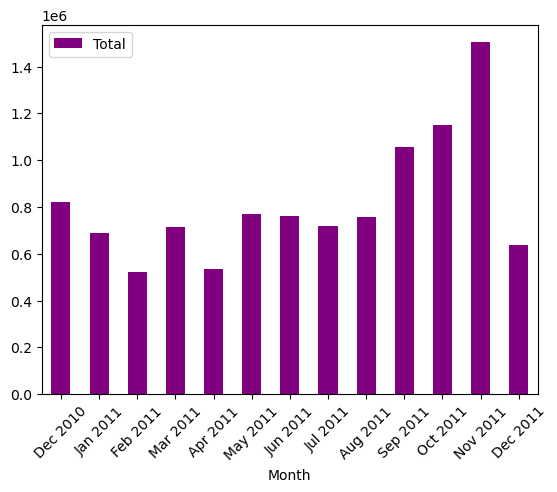

In [39]:
monthly_sales.plot.bar(xlabel="Month", rot=45, color="purple");
    

We see that top 3 months with highest sales were September, October and November 2011 with the pick in November suggesting pre-Christmas shopping.

Now we move on to see how sales are distributed during the week.

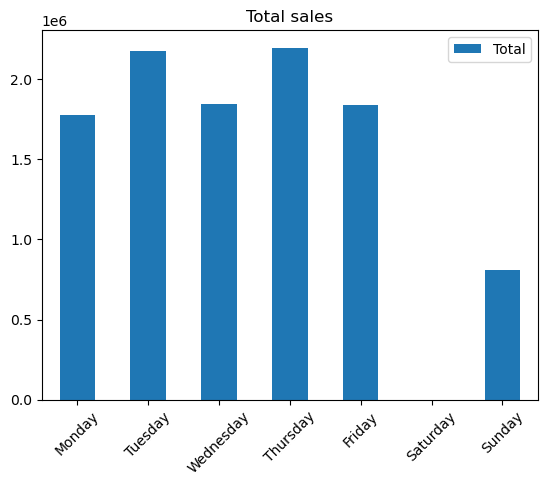

In [40]:
days=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
(sales.groupby(sales.index.day_name()).sum()).reindex(days).plot.bar(rot=45, xlabel="", title="Total sales");

Next, we will examine transaction volume by day of the week

In [41]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

(retail.groupby(retail["InvoiceDate"].dt.day_name())[["Total"]]
     .count()
     .reindex(days)
     .rename_axis("Day")
     .rename(columns={"Total":"Number of sales"})
).fillna(0)

,Number of sales
Day,
Monday,92466
Tuesday,98726
Wednesday,91467
Thursday,100213
Friday,79667
Saturday,0
Sunday,62339


# Conlusion: 
We see that there are no transactions on Saturday which suggests that there is possibly a technical break/some other issuses on the website.
This may have also affected sales on Sunday which are lower than on other days. This should be inspected because online retail should be expected
to have biggest sales on the weekend.

Next we move to trends across the days of the month.

In [42]:
daily_sales=retail.groupby(retail["InvoiceDate"].dt.day)[["Total"]].sum()
daily_sales.head()

,Total
InvoiceDate,
1,320753.7
2,303761.92
3,329432.33
4,384256.05
5,411756.66


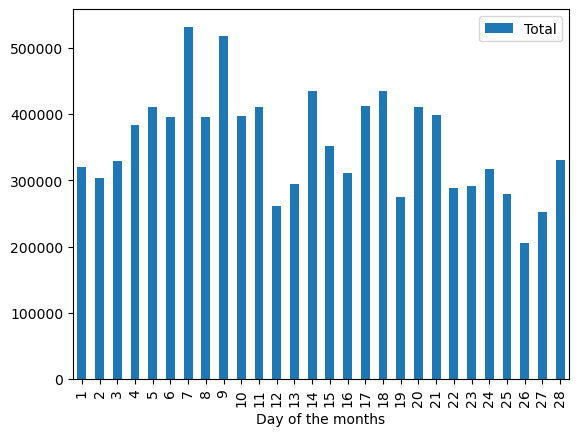

In [43]:
daily_sales.iloc[:28].plot.bar(xlabel="Day of the months"); #We disregarded days 29-31 because they do not appear in all months.

# Conclusions:
We observe a peak in total sales around the 7th–9th days of the month, followed by relatively stable sales during the middle of the month and a decline toward the end of the month. One possible explanation is that customers tend to make more purchases shortly after receiving their salaries. This pattern may suggest that promotional or advertising campaigns could be particularly effective during the early part of the month.

We move to last step of time-based analysis namely hourly trends.

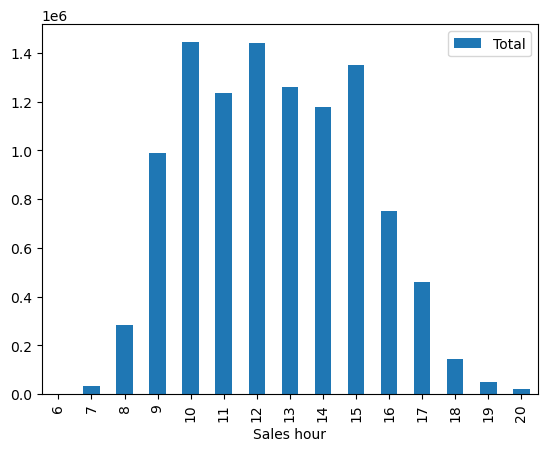

In [44]:
retail.groupby(retail["InvoiceHour"])[["Total"]].sum().plot.bar(xlabel="Sales hour");

# Conlusions:
Sales activity is highest between 10:00 and 15:00, particularly around midday. Then sales gradually decrease with minimal activity in the late evenings
and early mornings. This suggests that promotional campaigns may be the most effective in those time periods with lover sales.

retail.head()

# PRODUCTS ANALYSIS

In [45]:
retail.head()

,StockCode,Description,UnitPrice,Quantity,Total,CustomerID,InvoiceNo,InvoiceDate,InvoiceHour,Country
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2.55,6,15.3,17850,536365,2010-12-01,8,United Kingdom
1,71053,WHITE METAL LANTERN,3.39,6,20.34,17850,536365,2010-12-01,8,United Kingdom
2,84406B,CREAM CUPID HEARTS COAT HANGER,2.75,8,22.0,17850,536365,2010-12-01,8,United Kingdom
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,3.39,6,20.34,17850,536365,2010-12-01,8,United Kingdom
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,3.39,6,20.34,17850,536365,2010-12-01,8,United Kingdom


In [46]:
product_sales_sum=retail.groupby(["StockCode","Description"])[["Total"]].sum().sort_values("Total", ascending=False).reset_index()
# We group by Description and StockCode to avoid merging two different products with the same description.

Top 10 products by total revenue

In [48]:
product_sales_sum.iloc[:10]

,StockCode,Description,Total
0,DOT,DOTCOM POSTAGE,206248.77
1,22423,REGENCY CAKESTAND 3 TIER,174156.54
2,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.6
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
4,47566,PARTY BUNTING,99445.23
5,85099B,JUMBO BAG RED RETROSPOT,94159.81
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
7,POST,POSTAGE,78101.88
8,M,Manual,77750.27
9,23084,RABBIT NIGHT LIGHT,66870.03


Top 10 products by number of sales

In [50]:
product_sales_count=retail.groupby(["StockCode","Description"])[["Total"]].count().sort_values("Total", ascending=False).reset_index()

In [51]:
product_sales_count.iloc[:10]

,StockCode,Description,Total
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2244
1,85099B,JUMBO BAG RED RETROSPOT,2109
2,22423,REGENCY CAKESTAND 3 TIER,2007
3,47566,PARTY BUNTING,1699
4,20725,LUNCH BAG RED RETROSPOT,1581
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1476
6,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1392
7,21212,PACK OF 72 RETROSPOT CAKE CASES,1352
8,20727,LUNCH BAG BLACK SKULL.,1301
9,22457,NATURAL SLATE HEART CHALKBOARD,1255


Products in both tables:

In [52]:
product_sales_sum.iloc[:10].merge(product_sales_count.iloc[:10], on="StockCode", how="inner")[["Description_x"]]

,Description_x
0,REGENCY CAKESTAND 3 TIER
1,WHITE HANGING HEART T-LIGHT HOLDER
2,PARTY BUNTING
3,JUMBO BAG RED RETROSPOT
